# Audit 4 — Response magnitude and DEG counts in the Cytokine Dictionary (Oesinghaus et al.)

The Cytokine Dictionary, the reference paper of the Parse dataset, summarizes each cytokine x cell type by the **number of DEGs** (padj < 0.05, |log2FC| > 0.25) and a **response magnitude** (Euclidean distance of log2 expression to the **PBS** controls). If PBS carries a non-specific shift, biologically inert cytokines should also show DEGs and a sizeable magnitude, and these should disappear with the inert-cytokine reference.

**Approximation of the paper's pipeline:** pseudobulk log2(CPM + 1) per donor x cell type x cytokine (merged cell types as in the paper: B, CD4 T, CD8 T subsets merged), a paired t-test across donors against the reference, Benjamini-Hochberg, the paper's thresholds; magnitude = Euclidean norm of the mean log2 difference over expressed genes. References: **PBS** (as in the paper) and the **mean of the inert cytokines** (leave-one-out for inert cytokines).

In [1]:
import os
import numpy as np, pandas as pd
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt, seaborn as sns

CACHE_DIR = "data/parse10m/cache"
RESULTS_DIR = "results/dictionary_audit"
os.makedirs(RESULTS_DIR, exist_ok=True)
CONTROL = "PBS"
INERT = ["Noggin", "Decorin", "PSPN", "GDNF", "Megalin", "PRL", "EPO", "TPO", "FGF-beta", "EGF", "HGF", "VEGF", "IGF-1"]
CELL_TYPES = ["B", "CD4 T", "CD8 T", "CD14 Mono", "CD16 Mono", "NK"]
MIN_CELLS = 50; MIN_DONORS = 6; MIN_CPM = 10
PADJ, LFC = 0.05, 0.25

sums = np.load(os.path.join(CACHE_DIR, "pb_sums.npy"))
meta = pd.read_pickle(os.path.join(CACHE_DIR, "pb_meta.pkl")).reset_index(drop=True)
key = meta[["donor", "cell_type", "cytokine"]].astype(str).agg("|".join, axis=1)
codes, uniq = pd.factorize(key)
FULL = np.zeros((len(uniq), sums.shape[1])); np.add.at(FULL, codes, sums)
NC = np.bincount(codes, weights=meta.n_cells.to_numpy(), minlength=len(uniq))
IDX = {tuple(u.split("|")): i for i, u in enumerate(uniq) if NC[i] >= MIN_CELLS}
def log2cpm(x): return np.log2(x / max(x.sum(), 1) * 1e6 + 1)
CYTOS = sorted({k[2] for k in IDX if k[2] != CONTROL})
DONORS = sorted({k[0] for k in IDX})

## 1. DEG counts and magnitude per cytokine x cell type, for both references

In [2]:
def bh(p):
    p = np.asarray(p); n = len(p); o = np.argsort(p); r = np.empty(n); r[o] = np.arange(1, n + 1)
    q = p * n / r; q_sorted = np.minimum.accumulate(q[o][::-1])[::-1]; out = np.empty(n); out[o] = np.minimum(q_sorted, 1); return out

rows = []
for ct in CELL_TYPES:
    prof = {(d, c): log2cpm(FULL[IDX[(d, ct, c)]]) for d in DONORS for c in CYTOS + [CONTROL] if (d, ct, c) in IDX}
    pbs_mean = np.mean([prof[(d, CONTROL)] for d in DONORS if (d, CONTROL) in prof], 0)
    expressed = (2 ** pbs_mean - 1) >= MIN_CPM
    for c in CYTOS:
        for ref in ["PBS", "inert"]:
            diffs = []
            for d in DONORS:
                if (d, c) not in prof: continue
                if ref == "PBS":
                    if (d, CONTROL) not in prof: continue
                    r = prof[(d, CONTROL)]
                else:
                    others = [prof[(d, k)] for k in INERT if k != c and (d, k) in prof]
                    if len(others) < 3: continue
                    r = np.mean(others, 0)
                diffs.append((prof[(d, c)] - r)[expressed])
            if len(diffs) < MIN_DONORS: continue
            D = np.array(diffs); lfc = D.mean(0)
            p = ttest_1samp(D, 0, axis=0).pvalue; p = np.where(np.isnan(p), 1, p)
            q = bh(p)
            rows.append(dict(cell_type=ct, cytokine=c, inert=c in INERT, reference=ref, n_donors=len(diffs),
                             n_deg=int(((q < PADJ) & (np.abs(lfc) > LFC)).sum()), magnitude=float(np.linalg.norm(lfc))))
    print(ct, "done")
RES = pd.DataFrame(rows)
RES.to_csv(f"{RESULTS_DIR}/deg_and_magnitude.csv", index=False)

B done
CD4 T done
CD8 T done
CD14 Mono done
CD16 Mono done
NK done


## 2. Summary: inert vs immune cytokines, PBS vs inert reference

n  median_deg  mean_deg  share_with_deg  share_10plus_deg  \
reference inert                                                                
PBS       False  462       458.5    852.86             1.0               1.0   
          True    78       325.5    412.24             1.0               1.0   
inert     False  462       322.5    772.34             1.0               1.0   
          True    78       317.0    345.99             1.0               1.0   

                 median_magnitude  
reference inert                    
PBS       False             15.13  
          True              14.27  
inert     False             13.47  
          True              12.91

inert_share_with_deg       inert_median_deg         \
reference                  PBS inert              PBS  inert   
cell_type                                                      
B                          1.0   1.0            443.0  399.0   
CD14 Mono                  1.0   1.0            407.0  363.0   
CD16 Mono                  1.0   1.0            218.0  199.0   
CD4 T                      1.0   1.0            465.0  392.0   
CD8 T                      1.0   1.0            480.0  409.0   
NK                         1.0   1.0            270.0  189.0   

          inert_median_magnitude         
reference                    PBS  inert  
cell_type                                
B                          13.84  13.44  
CD14 Mono                  12.80  11.37  
CD16 Mono                  15.40  14.04  
CD4 T                      12.81  11.73  
CD8 T                      13.28  12.59  
NK                         15.11  14.54

,inert/immune magnitude (PBS),inert/immune magnitude (inert)
cell_type,,
B,0.92,1.00
CD14 Mono,0.90,0.89
CD16 Mono,0.92,0.95
CD4 T,0.97,0.96
CD8 T,0.94,0.99
NK,0.92,0.98


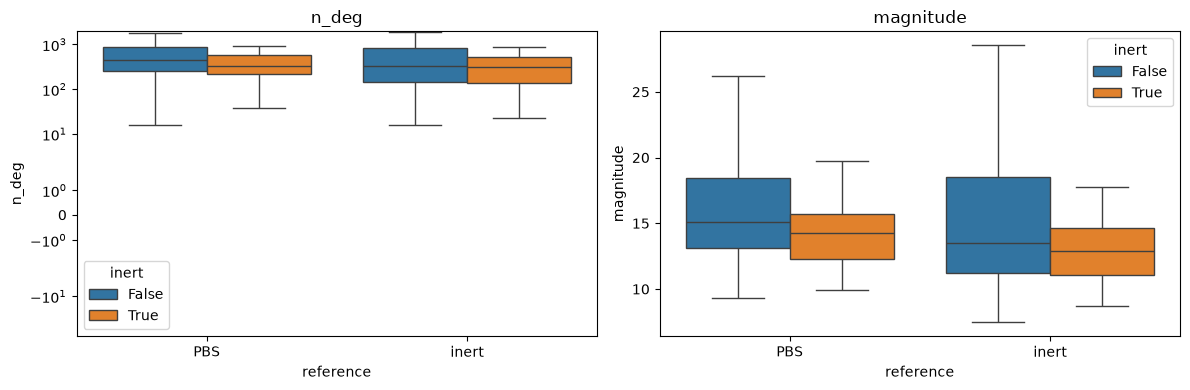

In [3]:
S = (RES.groupby(["reference", "inert"])
     .agg(n=("cytokine", "count"), median_deg=("n_deg", "median"), mean_deg=("n_deg", "mean"),
          share_with_deg=("n_deg", lambda x: (x > 0).mean()), share_10plus_deg=("n_deg", lambda x: (x >= 10).mean()),
          median_magnitude=("magnitude", "median")).round(2))
S.to_csv(f"{RESULTS_DIR}/summary.csv"); display(S)

PER_CT = RES[RES.inert].groupby(["cell_type", "reference"]).agg(
    inert_share_with_deg=("n_deg", lambda x: (x > 0).mean()), inert_median_deg=("n_deg", "median"),
    inert_median_magnitude=("magnitude", "median")).round(2).unstack("reference")
PER_CT.to_csv(f"{RESULTS_DIR}/inert_by_celltype.csv"); display(PER_CT)

# magnitude of inert cytokines relative to immune cytokines (the paper ranks cytokines by magnitude)
rel = RES.groupby(["reference", "cell_type"]).apply(
    lambda g: g[g.inert].magnitude.median() / g[~g.inert].magnitude.median()).unstack("reference").round(2)
rel.columns = [f"inert/immune magnitude ({c})" for c in rel.columns]
rel.to_csv(f"{RESULTS_DIR}/relative_magnitude.csv"); display(rel)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, metric in zip(ax, ["n_deg", "magnitude"]):
    sns.boxplot(data=RES, x="reference", y=metric, hue="inert", ax=a, showfliers=False)
    a.set_yscale("symlog" if metric == "n_deg" else "linear"); a.set_title(metric)
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/deg_magnitude.png", dpi=150, bbox_inches="tight"); plt.show()

## How to read
- **PBS reference:** if inert cytokines show DEGs in many cell types and a magnitude that is a large fraction of immune cytokines', the paper's per-cytokine tables contain the PBS shift.
- **Inert reference:** DEGs of inert cytokines should drop to about zero, while immune cytokines keep theirs.